<a href="https://colab.research.google.com/github/mekaeli/ELE767_CODES/blob/main/Copie_de_Laboratoire_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Segment de codes 1
# - Définir un gabarit de fonction Python (signature + valeur par défaut).
# - Montrer la structure attendue d'une docstring (arguments, retours, note).

def nom_de_la_fonction(argument1, argument2 =" valeur par defaut "):
    pass

    """
    NOM_DE_LA_FONCTION # en majuscule

    breve description de la fonction

    @Arguments :
        argument1 { type voulu pour l’argument1 } : description de ce que doit etre l
        ’argument1
        argument2 { type voulu pour l’argument2 } : description de ce que doit etre l
        ’argument2
        # ( facultatif ) explication du choix pour la valeur par defaut

    @Return :
        { type de l’objet retourne par la fonction } : description de l’objet
        retourne par la fonction
        # Si d’autres objets sont retournes , la meme syntaxe est utilisee pour
        chaque objet .

    ( facultatif ) Note : Information qui peut etre importante a connaitre pour l’
    utilisation de la fonction
    """


In [ ]:
# Segment de codes 2
# - Importer les bibliothèques nécessaires (TensorFlow/Keras, NumPy, Pandas, Matplotlib, SciPy, scikit-learn).
# - Activer l'affichage des figures Matplotlib directement dans le notebook.

import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import KFold
# Pour l’affichage des figures sans plt . show ()
%matplotlib inline

In [ ]:
# Segment de codes 3
# - Lister le contenu du dossier courant (équivalent de `ls -lah`).

!ls -lah



total 25M
drwxr-xr-x 1 root root 4.0K Mar 29 23:00 .
drwxr-xr-x 1 root root 4.0K Mar 29 19:20 ..
drwxr-xr-x 4 root root 4.0K Mar 23 13:29 .config
-rw-r--r-- 1 root root  25M Mar 29 23:01 data.csv
-rw-r--r-- 1 root root 155K Mar 29 23:00 mystere.csv
drwxr-xr-x 1 root root 4.0K Mar 23 13:29 sample_data


In [ ]:
# Segment de codes 4
# - Charger le fichier `data.csv` dans un DataFrame Pandas.
# Transfert des datasets vers des variables(DataFrames)

data_ds=pd.read_csv("data.csv")

In [ ]:
# Segment de codes 5
# - Afficher un résumé du DataFrame (types, valeurs non-nulles) avec `info()`.
# - Afficher un aperçu les 5 premières lignes avec `head()`.
# - Afficher un aperçu les 5 dernières lignes avec `tail()`.

print("__data__")
print(data_ds.info())
print(data_ds.head())
print(data_ds.tail())

__data__
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 890 entries, 0 to 889
Columns: 1561 entries, W0_MS_0 to number
dtypes: float64(1560), int64(1)
memory usage: 10.6 MB
None
    W0_MS_0   W0_MS_1   W0_MS_2   W0_MS_3   W0_MS_4   W0_MS_5   W0_MS_6  \
0  1.011981  2.142074  0.588728 -0.692308 -0.203841  1.042901 -0.537213   
1  0.083026  2.450909  0.818768  3.092884 -0.610867  4.112420  0.218586   
2  0.127918  1.936767  0.395461  1.011786 -0.208603  0.058295 -0.453895   
3  0.673839  1.831173  2.084694  0.548835 -0.690189  0.056046  0.763344   
4  2.182024 -0.060605 -0.000992  1.056996 -0.412494 -0.210797  1.100925   

    W0_MS_7   W0_MS_8   W0_MS_9  ...  W59_MD_4  W59_MD_5  W59_MD_6  W59_MD_7  \
0  0.498876 -0.680100 -0.737847  ...  0.581696 -0.422061 -0.210426 -0.492524   
1  0.147865  0.820458  1.024225  ... -0.554939 -0.722586 -0.363003 -0.661282   
2  1.157127 -0.097942  1.268917  ... -0.578180 -0.587715 -0.715070 -0.785123   
3 -0.764594 -0.405546  0.371929  ... -0.697126 -

In [ ]:
# Segment de codes 6
# - Mélanger (shuffle) les lignes de la base de données.
# - Séparer les variables d'entrée (features) et la sortie `number` (labels).
# - Découper une fois en train/test via K-Fold (k=n_fold) et conserver le 1er split.
# - Convertir train/test en `tf.data.Dataset`, mélanger et regrouper en batches pour `model.fit`.

def create_sets(data_ds,n_fold=5) :
  """
  CREATE_SETS
  Transforme les bases de donnees afin d’etre compatible avec l’ entrainement
  du modele avec la methode " fit "

  @Arguments :
    data_ds {pd.DataFrame } : Base de donnees d’ entrainement
    n_fold { int } : nombre de division pour le kfold

  @Return :
    { tensorflow.BatchDataset } : Base de donnees d’ entrainement
    { tensorflow.BatchDataset } : Base de donnees de test
  """
  # Melanger les valeurs de la base de donnees
  data=data_ds.sample(frac=1).reset_index(drop=True)

  # Diviser les variables et les resultats
  data_output=data.pop("number")

  # Extraire les indexes pour le kfold une seule fois
  for train_index,test_index in KFold(n_fold).split(data) :
    # Creer la base de donnees d’ entrainement
    X_train=(data.values)[train_index]
    y_train=(data_output.values)[train_index]

    ### Creer la base de donnees de test
    X_test=(data.values)[test_index]
    y_test=(data_output.values)[test_index]
    break

  # Transformer les bases de donnees pour etre utilisees directement dans fit
  # Les donnees sont melangees une autre fois avant d’etre retournees
  train_set=tf.data.Dataset.from_tensor_slices((X_train,y_train))
  train_set=train_set.shuffle(len(X_train))
  train_set=train_set.batch(1)

  test_set=tf.data.Dataset.from_tensor_slices((X_test,y_test))
  test_set=test_set.shuffle(len(X_test))
  test_set=test_set.batch(1)

  return train_set, test_set

In [ ]:
# Segment de codes 7
# - Créer un modèle Keras séquentiel (réseau de neurones simple).
# - Ajouter une couche Dense de sortie pour 4 classes avec activation sigmoïde.

# Creer un modele sequentiel
perceptron=tf.keras.Sequential([
  layers.Dense(4, activation='sigmoid', dtype='float64')
])
# Compiler le modele pour l’entrainement
perceptron.compile(optimizer='SGD',
                loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                metrics=['accuracy'])

In [ ]:
# Segment de codes 8
# - Définir une fonction d'entraînement générique pour un modèle Keras.
# - Créer les ensembles train/test via `create_sets` (K-Fold).
# - Évaluer le modèle avant entraînement, puis à chaque époque sur train et test.
# - Enregistrer l'historique des métriques (accuracy/loss) dans un dictionnaire retourné.

def training(model, data_ds, epochs=10, n_fold=5, verbose_train=1, verbose_test=1):
    """
    TRAINING

    Fonction servant a entrainer un model et en verifiant les capacites du modele sur les donnees de test

    @Arguments :
        model {tensorflow.python.keras.engine.sequential.Sequential} : Modele   tensorflow a entrainer
        data_ds {pd.DataFrame} : Base de données d'entrainement
        epochs {int} : Nombre d'epoques a faire pour l'entrainement du model
        n_fold {int} : Nombre de fold pour le kfold
        verbose_train {int} : 1 pour afficher l'avancement de l'apprentissage,  0 aucun affichage
        verbose_test {int} : 1 pour afficher l'avancement de l'evaluation, 0 aucun affichage

    @Return :
        {dict} :'train_accuracy' {list} : precision du modele sur la base d'entrainement
        'train_loss' {list} : perte du modele sur la base d'entrainement
        'test_accuracy' {list} : precision du modele sur la base de test
        'test_loss' {list} : perte du modele sur la base de test
    """
    # Initialisation des listes recevants
    train_accuracy=[]
    train_loss=[]
    test_accuracy=[]
    test_loss=[]

    # Creer les bases de donnees pour l'entrainement
    train_set, test_set=create_sets(data_ds, n_fold)

    # Evaluer le modele avant l'entrainement
    result=model.evaluate(train_set, verbose=verbose_train)
    train_accuracy.append(result[1])
    train_loss.append(result[0])

    result=model.evaluate(test_set, verbose=verbose_test)
    test_accuracy.append(result[1])
    test_loss.append(result[0])

    # Boucle d'entrainement
    for e in range(epochs):
        print('Epoch #{}'.format(e + 1))

        result=model.fit(train_set, epochs=1, verbose=verbose_train)
        train_accuracy.append(result.history['accuracy'][-1])
        train_loss.append(result.history['loss'][-1])

        result=model.evaluate(test_set, verbose=verbose_test)
        test_accuracy.append(result[1])
        test_loss.append(result[0])

    return {
        'train_accuracy': train_accuracy,
        'train_loss': train_loss,
        'test_accuracy': test_accuracy,
        'test_loss': test_loss
    }

In [ ]:
# Segment de codes 9
# - Définir une fonction utilitaire qui trace les courbes d'apprentissage (accuracy et loss).
# - Créer une figure avec deux sous-graphes : précision (train/test) et perte (train/test).
# - Mettre en forme les axes, la grille et la légende, puis afficher la figure.

def figure(training_dict,suptitle,figsize=(12 ,6)):
    """
    FIGURE

    Produit une figure avec les statistiques de la fonction 'training '

    @Arguments :
        training_dict { dict(list)} : Dictionnaire retournee par la fonction
        training
        figsize { Tuple } : Dimension de la figure
    """
    # Demarre une figure avec la taille(en pouce) donner en arguments
    plt.figure(figsize=figsize,facecolor='w')

    # Titre global de la figure
    plt.suptitle(suptitle)

    # Premiere sous - figure -> Precision du modele durant l' entrainement
    plt.subplot(121)
    plt.title('Precision du modele')
    plt.xlabel('Nombre d\' epoques')
    plt.ylabel('Precision de la classification')
    # Produit une courbe pour chaque base de donnees
    plt.plot(training_dict ['train_accuracy'], 'r', label='training')
    plt.plot(training_dict ['test_accuracy'], 'y', label='test')
    # Limite de la precision pour rendre les valeurs entre 0% et 100% visibles
    plt.ylim(0 ,1.01)
    # Produire un grille en arriere - plan
    # plt.grid(True,which=' major ', color='#666666 ',linestyle='-')
    plt.grid()
    plt.minorticks_on()
    plt.grid(True,which='minor', color='#999999', linestyle='-', alpha=0.2)
    plt.legend() # Afficher les labels des courbes

    # Deuxieme sous - figure -> Resultat de la fonction de perte durant l'entrainement
    plt.subplot(122)
    plt.title('Perte du modele')
    plt.xlabel('Nombre d\' epoques')
    plt.ylabel('Resultat de la fonction de perte')
    # Produire une courbe pour chaque base de donnees
    plt.plot(training_dict ['train_loss'],'r', label='training')
    plt.plot(training_dict ['test_loss'],'y', label='test');
    # S'assurer que la valeur minimum de l'ordonnee soit 0
    plt.ylim(0) ;
    # Produire un grille en arriere - plan
    # plt.grid(True,which=' major ', color='#666666 ',linestyle='-')
    plt.grid()
    plt.minorticks_on()
    plt.grid(True,which='minor', color='#999999', linestyle='-', alpha=0.2)
    plt.legend()
    return

In [ ]:
# Segment de codes 10
# - Lancer l'entraînement du perceptron avec la fonction `training`.
# - Stocker les métriques d'apprentissage (accuracy/loss train/test) dans `result`.

result=training(perceptron, data_ds, epochs=25)

712/712 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2654 - loss: 1.4146
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2022 - loss: 1.4771
Epoch #1
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7233 - loss: 0.7587
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8258 - loss: 0.4748
Epoch #2
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9256 - loss: 0.2138
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8820 - loss: 0.4551
Epoch #3
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9677 - loss: 0.0875
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8652 - loss: 0.5213
Epoch #4
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9888 - loss: 0.0210
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8989 - loss: 0.4352
Epoch #5
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9944 - loss: 0.0092
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9045 - loss: 0.4565
Epoch #6
712/712 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - acc

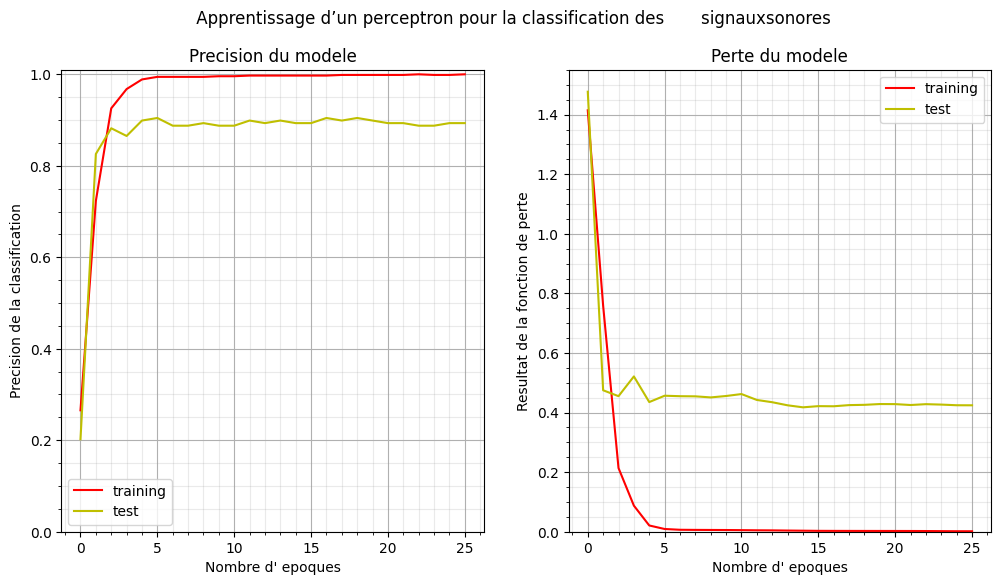

In [ ]:
# Segment de codes 11
# - Afficher les courbes d'apprentissage du perceptron (accuracy/loss).
# - Utiliser les métriques stockées dans `result` avec la fonction `figure`.

figure(result, " Apprentissage d’un perceptron pour la classification des       signauxsonores")


In [ ]:
import os

# Segment de codes 12
# - Sauvegarder le perceptron entraîné au format Keras.
# - Écrire le fichier dans `modeles/perceptron.keras`.

# Créer le dossier 'modeles' s'il n'existe pas
os.makedirs('modeles', exist_ok=True)

perceptron.save('modeles/perceptron.keras')

712/712 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2556 - loss: 1.4482
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2416 - loss: 1.4532
Epoch #1
712/712 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6559 - loss: 0.8392
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8258 - loss: 0.4221
Epoch #2
712/712 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9073 - loss: 0.2531
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9438 - loss: 0.1902
Epoch #3
712/712 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9747 - loss: 0.1097
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9213 - loss: 0.1982
Epoch #4
712/712 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9958 - loss: 0.0543
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9551 - loss: 0.1732
Epoch #5
712/712 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9986 - loss: 0.0294
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9494 - loss: 0.1770
Epoch #6
712/712 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 512)            │       799,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801,286 (6.11 MB)

 Trainable params: 801,284 (6.11 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

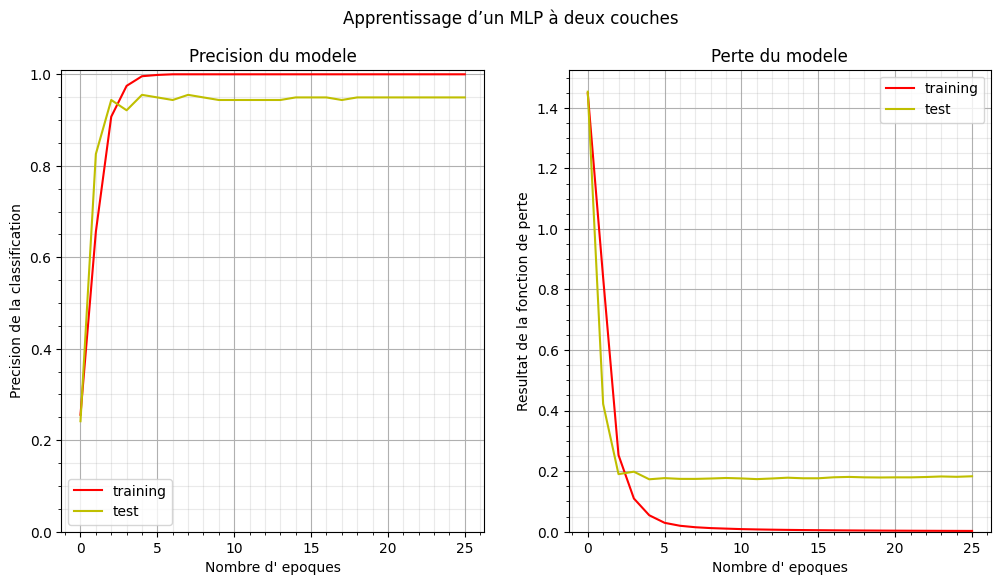

In [ ]:
# Segment de codes 13
# - Créer un MLP (réseau perceptron multi-couches) à 2 couches Dense.
# - Compiler le modèle (optimiseur SGD, entropie croisée, accuracy).
# - Entraîner le modèle avec `training` et récupérer les métriques dans `result_mlp2c`.
# - Afficher le résumé (`summary`), tracer les courbes (`figure`), puis sauvegarder le modèle.

#création d’un MLP à deux couches
mlp2c=tf.keras.Sequential([
    layers.Dense(512, activation='sigmoid', dtype='float64'),
    layers.Dense(4, activation='sigmoid', dtype='float64')
])

# Compiler le modele pour l’entrainement
mlp2c.compile(optimizer='SGD',
             loss=tf.keras.losses.SparseCategoricalCrossentropy(),
             metrics=['accuracy'])

# Entraîner le modèle(MLP à deux couches)
result_mlp2c=training(mlp2c, data_ds, epochs=25)

# Vérification de la structure du modele
mlp2c.summary()

# Afficher les statistiques du modèle
figure(result_mlp2c, "Apprentissage d’un MLP à deux couches")

# Enregistrer le modèle
mlp2c.save('modeles/mlp2c.keras')

In [ ]:
# Segment de codes 14
# - Définir l'entrée du modèle avec la forme attendue des données.
# - Construire un petit réseau (Dense -> Dense) via l'API fonctionnelle Keras.
# - Compiler le modèle et afficher sa structure avec `summary()`.
# Creer une couche d’entree
# La dimension des Tensors utilises est de(None,1, 1560)

model_input=layers.Input(shape=(None, 1, data_ds.shape [1] -1))

# Creer les couches du reseau de neurones
x=layers.Dense(512, activation='sigmoid',dtype='float64')(model_input)
model=layers.Dense(4, activation='sigmoid', dtype='float64')(x)

# Valider le modele
model=tf.keras.Model(model_input, model)

# Compiler le modele pour l’ entrainement
model.compile(optimizer='SGD',
              loss=tf.keras.losses.SparseCategoricalCrossentropy() ,
              metrics=['accuracy'])

# vérification de la steucture du modele
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, None, 1, 1560)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, None, 1, 512)   │       799,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, None, 1, 4)     │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801,284 (6.11 MB)

 Trainable params: 801,284 (6.11 MB)

 Non-trainable params: 0 (0.00 B)

712/712 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2093 - loss: 1.4238
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2079 - loss: 1.4140
Epoch #1
712/712 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6039 - loss: 0.9099
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9101 - loss: 0.3509
Epoch #2
712/712 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9270 - loss: 0.2575
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7978 - loss: 0.4855
Epoch #3
712/712 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9663 - loss: 0.1194
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8876 - loss: 0.2501
Epoch #4
712/712 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9874 - loss: 0.0635
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8427 - loss: 0.4232
Epoch #5
712/712 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9958 - loss: 0.0403
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9213 - loss: 0.2290
Epoch #6
712/712 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 512)            │       799,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801,286 (6.11 MB)

 Trainable params: 801,284 (6.11 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

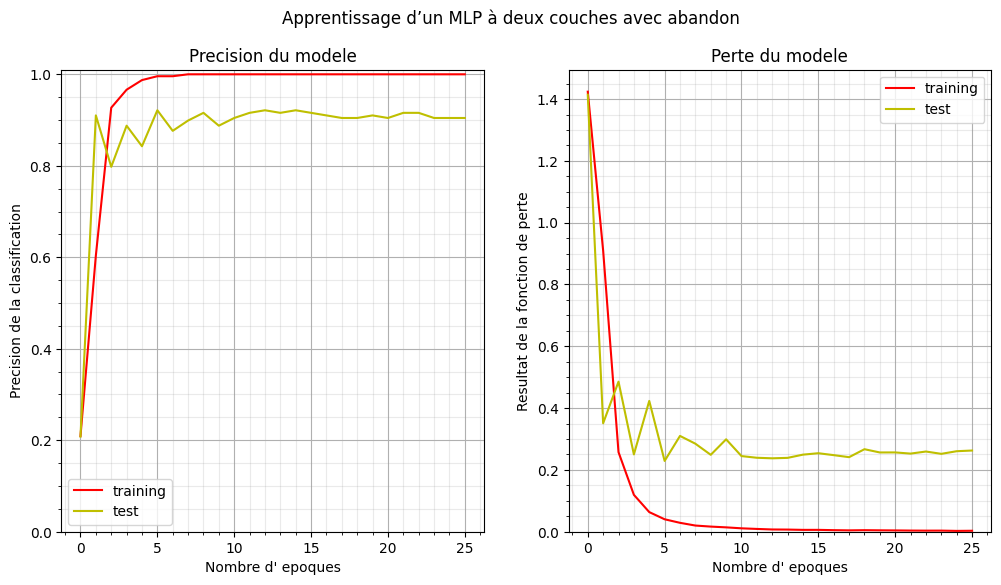

In [ ]:
# Segment de codes 15
# - Créer un MLP à 2 couches avec une couche Dropout (abandon).
# - Compiler le modèle, l'entraîner, afficher le résumé et tracer les courbes d'apprentissage.

# Création d’un MLP à deux couches avec abandon
mlp2cd=tf.keras.Sequential([
    layers.Dense(512, activation='sigmoid', dtype='float64'),
    layers.Dropout(0.2, dtype='float64'),
    layers.Dense(4, activation='sigmoid', dtype='float64')
])

# Compiler le modele pour l’entrainement
mlp2cd.compile(optimizer='SGD',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

# Entraîner le modèle(MLP à deux couches avec abandon)
result_mlp2cd=training(mlp2cd, data_ds, epochs=25)

# Vérification de la structure du modele
mlp2cd.summary()

# Afficher les statistiques du modèle
figure(result_mlp2cd, "Apprentissage d’un MLP à deux couches avec abandon")

# Enregistrer le modèle
mlp2cd.save('modeles/mlp2cd.keras')

712/712 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2935 - loss: 1.5324
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2247 - loss: 1.6616
Epoch #1
712/712 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7275 - loss: 0.6461
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8596 - loss: 0.3349
Epoch #2
712/712 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9522 - loss: 0.1518
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9213 - loss: 0.2064
Epoch #3
712/712 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9860 - loss: 0.0459
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8764 - loss: 0.3143
Epoch #4
712/712 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9902 - loss: 0.0249
178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9101 - loss: 0.2273
Epoch #5
712/712 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 1.0000 - loss: 0.0033
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9045 - loss: 0.2340
Epoch #6
712/712 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - acc

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                │ (None, 512)            │       799,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 4)              │           516 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_2 (Softmax)             │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 865,414 (6.60 MB)

 Trainable params: 865,412 (6.60 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

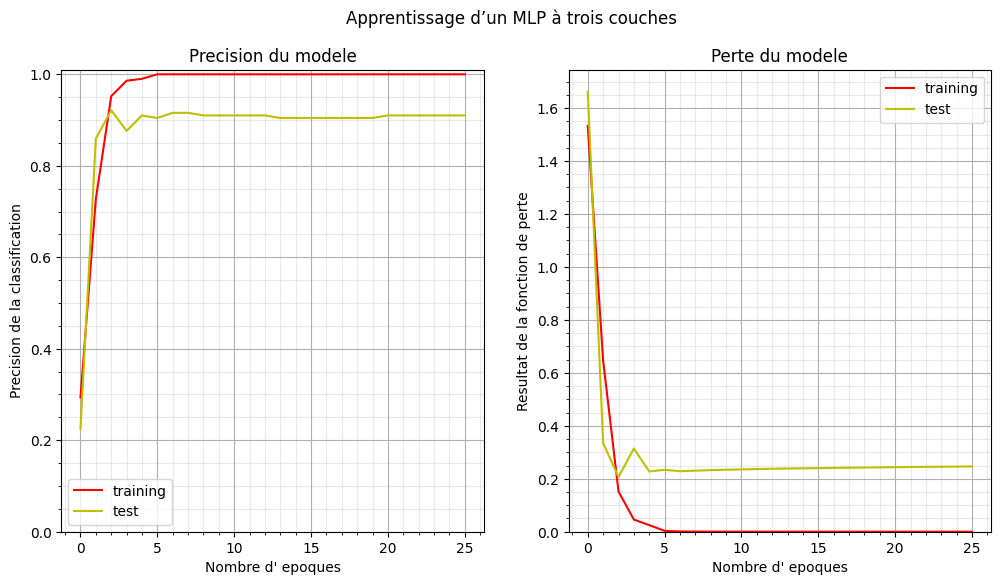

In [ ]:
# Segment de codes 16
# - Créer un MLP à 3 couches (2 couches cachées + sortie Softmax).
# - Compiler le modèle, l'entraîner, afficher le résumé et tracer les courbes d'apprentissage.

# Création d’un MLP à trois couches sans abandon
mlp3c=tf.keras.Sequential([
    layers.Dense(512, activation='relu', dtype='float64'),
    layers.Dense(128, activation='relu', dtype='float64'),
    layers.Dense(4, dtype='float64'),
    layers.Softmax(dtype='float64')
])

# Compiler le modele pour l’entrainement
mlp3c.compile(optimizer='SGD',
             loss=tf.keras.losses.SparseCategoricalCrossentropy(),
             metrics=['accuracy'])

# Entraîner le modèle(MLP à trois couches)
result_mlp3c=training(mlp3c, data_ds, epochs=25)

# Vérification de la structure du modele
mlp3c.summary()

# Afficher les statistiques du modèle
figure(result_mlp3c, "Apprentissage d’un MLP à trois couches")

# Enregistrer le modèle
mlp3c.save('modeles/mlp3c.keras')

### 3.13 — En profondeur : modèle de votre choix (RNN)

**Modèle choisi.** Un réseau de neurones récurrent **SimpleRNN** (RNN « vanille ») est conçu pour modéliser des dépendances séquentielles via un état caché mis à jour à chaque pas de temps. Ici, chaque exemple $(x_1,\dots,x_d)$ est interprété comme une séquence de longueur $d$ (un pas de temps par feature) afin d’utiliser une couche `SimpleRNN` comme extracteur de représentation avant la classification.

**Référence bibliographique.**
- J. L. Elman (1990). *Finding structure in time*. Cognitive Science, 14(2), 179–211.

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,644 (33.77 KB)

 Trainable params: 8,644 (33.77 KB)

 Non-trainable params: 0 (0.00 B)


===== Fold 1/5=====
Train loss=1.2374 | Train accuracy=0.4522
Test  loss=1.2492 | Test  accuracy=0.4438
Nouveau meilleur modèle sauvegardé: modeles/deep_313_rnn.keras

===== Fold 2/5=====
Train loss=1.3239 | Train accuracy=0.3511
Test  loss=1.3558 | Test  accuracy=0.3596

===== Fold 3/5=====
Train loss=1.1188 | Train accuracy=0.5295
Test  loss=1.1795 | Test  accuracy=0.5056
Nouveau meilleur modèle sauvegardé: modeles/deep_313_rnn.keras

===== Fold 4/5=====
Train loss=1.2389 | Train accuracy=0.4607
Test  loss=1.2820 | Test  accuracy=0.3764

===== Fold 5/5=====
Train loss=1.0947 | Train accuracy=0.5183
Test  loss=1.2926 | Test  accuracy=0.4326


,fold,train_loss,train_accuracy,test_loss,test_accuracy
0,1,1.237401,0.452247,1.249176,0.443820
1,2,1.323926,0.351124,1.355831,0.359551
2,3,1.118788,0.529494,1.179523,0.505618
3,4,1.238910,0.460674,1.282030,0.376404
4,5,1.094702,0.518258,1.292613,0.432584



Moyennes sur 5 folds :
Train loss moy.   : 1.2027
Train accuracy moy: 0.4624
Test  loss moy.   : 1.2718
Test  accuracy moy: 0.4236

Meilleur fold: 3(test accuracy=0.5056)
Modèle final sauvegardé : modeles/deep_313_rnn.keras


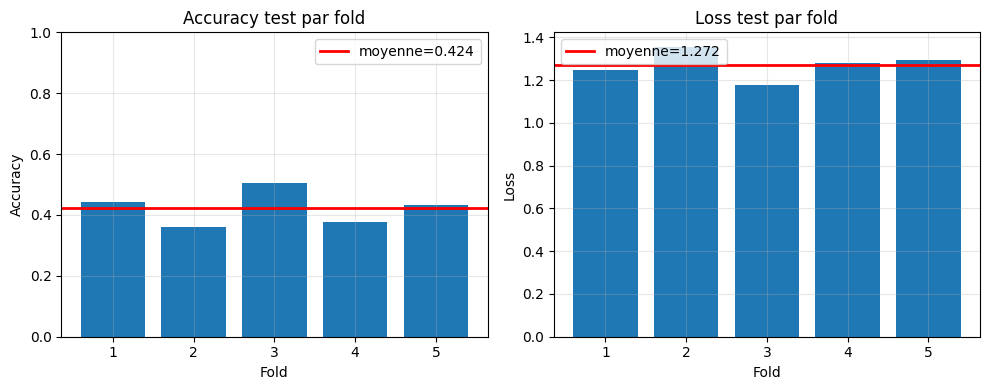

In [ ]:
# Segment de codes 16(suite) — 3.13(modèle profond au choix)
# - Présenter le modèle profond choisi (RNN) et préparer l'expérimentation demandée.
# - Préparer les données au format séquence et définir une fonction `build_rnn_model` (construction + compilation).
# - Lancer un entraînement/évaluation en K-Fold, suivre les métriques (train + test), et sauvegarder le meilleur modèle.
# - Pour (c), afficher aussi un graphique (folds + moyenne) sur les métriques de test.

from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import KFold
from tensorflow.keras import layers
import matplotlib.pyplot as plt

if "data_ds" not in globals():
    data_ds=pd.read_csv("data.csv")

# ----------------------------
# Hyperparamètres (explicites)
# ----------------------------
# Nombre de folds pour la validation croisée (k-fold).
N_FOLDS=5

# Nombre maximal d'époques d'entraînement par fold (peut être écourté via early-stopping).
EPOCHS=10

# Taille des mini-batchs pour l'entraînement/évaluation.
BATCH_SIZE=32

# Taux d'apprentissage de l'optimiseur Adam.
LEARNING_RATE=1e-3

# Graine aléatoire pour rendre le découpage k-fold reproductible.
RANDOM_STATE=42

# Nombre d'unités dans la couche RNN (SimpleRNN).
RNN_UNITS=64

# Nombre d'unités dans la couche Dense après la RNN.
DENSE_UNITS=64

# Nombre d'époques sans amélioration de val_accuracy avant arrêt anticipé.
EARLY_STOP_PATIENCE=3

# Taille max du buffer de shuffle (pour limiter la mémoire).
SHUFFLE_BUFFER_CAP=10_000

# Nom du fichier du meilleur modèle sauvegardé (meilleur fold).
SAVE_FILENAME="deep_313_rnn.keras"


def _prepare_xy(df: pd.DataFrame):
    """Prépare (X_seq, y, n_features, n_classes) à partir du DataFrame data.csv."""
    feature_cols=[c for c in df.columns if c != "number"]
    X=df[feature_cols].to_numpy(dtype=np.float32)
    y=df["number"].to_numpy(dtype=np.int64)

    # Assure des labels consécutifs 0..C-1 (sécurité si le CSV commence à 1).
    y_min=int(np.min(y))
    if y_min != 0:
        y=y - y_min

    n_features=X.shape[1]
    n_classes=int(np.max(y) + 1)

    # Interprétation "séquence" : (timesteps=n_features, channels=1)
    X_seq=X.reshape((-1, n_features, 1))
    return X_seq, y, n_features, n_classes


def _make_datasets(X_seq: np.ndarray, y: np.ndarray, train_idx, test_idx):
    """Crée des tf.data.Dataset (train/test) pour un fold donné."""
    X_train, y_train=X_seq[train_idx], y[train_idx]
    X_test, y_test=X_seq[test_idx], y[test_idx]

    shuffle_buf=min(len(train_idx), SHUFFLE_BUFFER_CAP)
    train_set=(
        tf.data.Dataset.from_tensor_slices((X_train, y_train))
        .shuffle(shuffle_buf)
        .batch(BATCH_SIZE)
    )
    test_set=tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)
    return train_set, test_set


def build_rnn_model(n_features: int, n_classes: int) -> tf.keras.Model:
    """Construit et compile un modèle RNN (SimpleRNN) pour la classification."""
    model=tf.keras.Sequential([
        layers.Input(shape=(n_features, 1), dtype="float32"),
        layers.SimpleRNN(RNN_UNITS),
        layers.Dense(DENSE_UNITS, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )
    return model


def _plot_fold_metrics(metrics_df: pd.DataFrame):
    """Affiche le graphique des métriques test par fold + ligne de moyenne."""
    mean_loss=float(metrics_df["test_loss"].mean())
    mean_acc=float(metrics_df["test_accuracy"].mean())

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.bar(metrics_df["fold"], metrics_df["test_accuracy"])
    plt.axhline(mean_acc, color="red", linewidth=2, label=f"moyenne={mean_acc:.3f}")
    plt.title("Accuracy test par fold")
    plt.xlabel("Fold")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.0)
    plt.grid(alpha=0.3)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.bar(metrics_df["fold"], metrics_df["test_loss"])
    plt.axhline(mean_loss, color="red", linewidth=2, label=f"moyenne={mean_loss:.3f}")
    plt.title("Loss test par fold")
    plt.xlabel("Fold")
    plt.ylabel("Loss")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()


# 3a) Préparation des données (X, y) à partir de data.csv
X_all_seq, y_all, n_features, n_classes=_prepare_xy(data_ds)

# Afficher la structure (un exemple de modèle)
_model_preview=build_rnn_model(n_features, n_classes)
_model_preview.summary()

# 3b) Entraînement/évaluation en k-fold avec k=5
kf=KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

fold_metrics=[]
best_fold_acc=-1.0
best_fold=None
save_path=Path("modeles") / SAVE_FILENAME
save_path.parent.mkdir(parents=True, exist_ok=True)

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_all_seq), start=1):
    print(f"\n===== Fold {fold_idx}/{N_FOLDS}=====")
    train_set, test_set=_make_datasets(X_all_seq, y_all, train_idx, test_idx)

    model_fold=build_rnn_model(n_features, n_classes)
    early_stop=tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=EARLY_STOP_PATIENCE,
        restore_best_weights=True,
    )
    model_fold.fit(
        train_set,
        validation_data=test_set,
        epochs=EPOCHS,
        verbose=0,
        callbacks=[early_stop],
    )

    # (a) Performance sur données d'apprentissage
    train_loss, train_acc=model_fold.evaluate(train_set, verbose=0)
    # (b) Généralisation sur données de test
    test_loss, test_acc=model_fold.evaluate(test_set, verbose=0)

    fold_metrics.append({
        "fold": fold_idx,
        "train_loss": float(train_loss),
        "train_accuracy": float(train_acc),
        "test_loss": float(test_loss),
        "test_accuracy": float(test_acc),
    })
    print(f"Train loss={train_loss:.4f} | Train accuracy={train_acc:.4f}")
    print(f"Test  loss={test_loss:.4f} | Test  accuracy={test_acc:.4f}")

    # 3d) Sauvegarde du modèle (meilleur fold)
    if float(test_acc) > best_fold_acc:
        best_fold_acc=float(test_acc)
        best_fold=fold_idx
        model_fold.save(save_path)
        print(f"Nouveau meilleur modèle sauvegardé: {save_path}")

# 3c) Affichage des résultats pour chaque fold + moyenne (+ graphique)
metrics_df=pd.DataFrame(fold_metrics)
display(metrics_df)

mean_train_loss=float(metrics_df["train_loss"].mean())
mean_train_acc=float(metrics_df["train_accuracy"].mean())
mean_test_loss=float(metrics_df["test_loss"].mean())
mean_test_acc=float(metrics_df["test_accuracy"].mean())

print("\nMoyennes sur 5 folds :")
print(f"Train loss moy.   : {mean_train_loss:.4f}")
print(f"Train accuracy moy: {mean_train_acc:.4f}")
print(f"Test  loss moy.   : {mean_test_loss:.4f}")
print(f"Test  accuracy moy: {mean_test_acc:.4f}")

print(f"\nMeilleur fold: {best_fold}(test accuracy={best_fold_acc:.4f})")
print(f"Modèle final sauvegardé : {save_path}")

_plot_fold_metrics(metrics_df)

In [ ]:
# Segment de codes 17
# - Charger le fichier `mystere.csv` dans un DataFrame Pandas.
# - Afficher un résumé du DataFrame (types, valeurs non-nulles) avec `info()`.
# - Convertir le DataFrame en `tf.data.Dataset` utilisable par Keras/TensorFlow.

# Transfert des datasets vers des variables(DataFrames)
_mystere_ds=pd.read_csv("mystere.csv")
print(_mystere_ds.info())

# Transformation de la base de donnees mystere en dataset TensorFlow
mystere_ds=tf.data.Dataset.from_tensor_slices(_mystere_ds.values)
mystere_set=mystere_ds.batch(1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Columns: 1560 entries, x0_MS_0 to W59_ED
dtypes: float64(1560)
memory usage: 61.1 KB
None


In [ ]:
# Segment de codes 18
# - Charger le modèle (perceptron) entraîné et sauvegardé au format `.keras`.
# - Appliquer le modèle sur l'ensemble mystère (`mystere_set`).
# - Convertir la sortie du réseau en classes en prenant l'index du maximum (`argmax`).

# Chargement du perceptron entraine precedement
model = tf.keras.models.load_model('modeles/perceptron.keras')
# Obtenir seulement l’index de la valeur la plus grande de la reponse du modele
np.argmax(model.predict(mystere_set), axis=1)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


array([2, 2, 1, 2, 0])

In [ ]:
# Segment de codes 19
# - Charger successivement plusieurs modèles sauvegardés (perceptron, MLP 2 couches, MLP 2 couches + dropout, MLP 3 couches).
# - Calculer la prédiction de chaque modèle sur `mystere_set` puis convertir en classes via `argmax`.
# - Regrouper toutes les prédictions dans un tableau NumPy (un modèle par ligne).
# - Extraire une prédiction "commune" en utilisant le mode statistique (vote majoritaire).

# Concevoir une liste vide prete a recevoir les resultats
result = []

# Voir la prediction de chaque modele
for model_dir in ['modeles/perceptron.keras', 'modeles/mlp2c.keras', 'modeles/mlp2cd.keras', 'modeles/mlp3c.keras']:
    try:
        model = tf.keras.models.load_model(model_dir)
        prediction = model.predict(mystere_set)
        # Retourne l’index ayant la plus grande valeur
        result.append(np.argmax(prediction, axis=1))
    except ValueError as e:
        print(f"Warning: Could not load model {model_dir}. Error: {e}")

# Transferer la liste en array de numpy
result = np.array(result)

# Afficher les resultats
print(" Resultat de tous les modeles ")
print(result)
print(" Resultat commun entre les modeles ")
print((stats.mode(result, axis=0))[0] )

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
 Resultat de tous les modeles 
[[2 2 1 2 0]
 [2 2 1 2 0]
 [2 2 1 2 0]]
 Resultat commun entre les modeles 
[2 2 1 2 0]


In [ ]:
# Segment de codes 20
# - Ajouter explicitement une couche `Softmax` à la fin du modèle courant (pour obtenir des probabilités de classes).
# - Recompiler le modèle après modification de l'architecture (nécessaire avant certaines opérations).
# - Afficher le résumé (`summary()`) pour vérifier la structure du modèle après ajout de la couche.

model.add(layers.Softmax(dtype='float64'))
# Recompiler le modele afin qu ’il puissent faire la prediction
model.compile(optimizer='SGD',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 512)            │       799,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │         2,052 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801,284 (6.11 MB)

 Trainable params: 801,284 (6.11 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Segment de codes 21
# - Compresser le dossier `modeles` en `modeles.zip` pour remise.

!zip -r modeles.zip ./modeles

updating: modeles/ (stored 0%)
updating: modeles/mlp2cd.keras (deflated 5%)
updating: modeles/deep_313_rnn.keras (deflated 24%)
updating: modeles/perceptron.keras (deflated 23%)
updating: modeles/mlp2c.keras (deflated 5%)
